# Models' Performances analysis 
Here we analyse aggregated models'performances 

In [10]:
import pandas as pd

In [11]:
df = pd.read_csv("./classifiers_performances.csv")

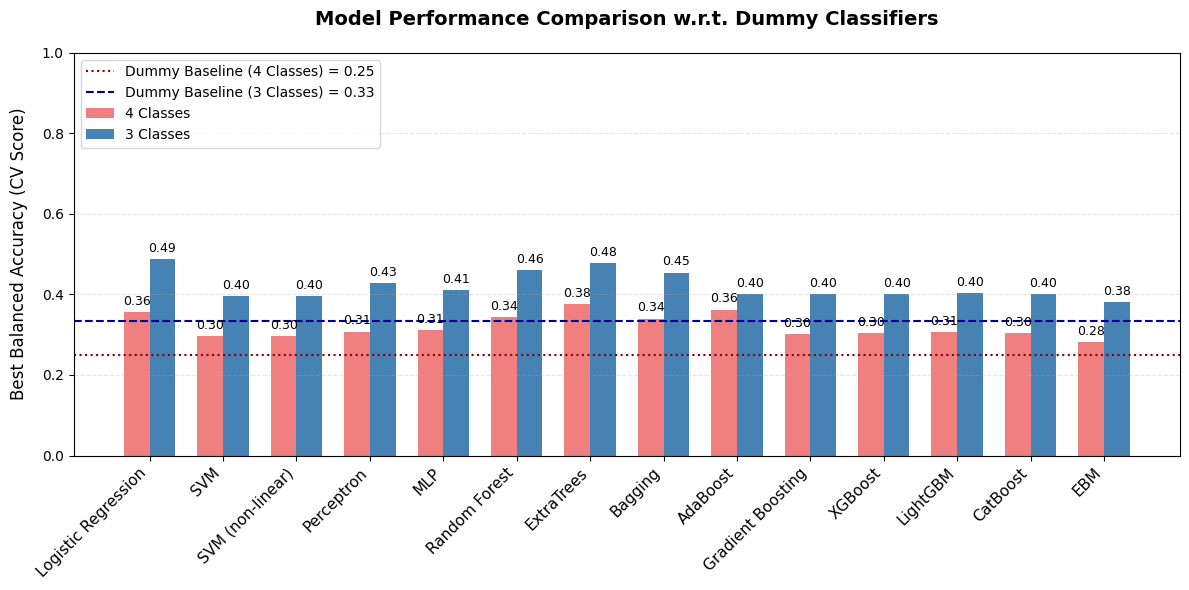

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Nomi dei classificatori testati
models = df['classifier'].tolist()

# Punteggi fittizi (sostituisci con i tuoi reali)
best_score_4classes = df['balanced_accuracy_4c'].tolist() 
best_score_3classes = df['balanced_accuracy_3c'].tolist()

x = np.arange(len(models))  
width = 0.35                 

plt.figure(figsize=(12, 6))

rects1 = plt.bar(x - width/2, best_score_4classes, width, label='4 Classes', color='lightcoral')
rects2 = plt.bar(x + width/2, best_score_3classes, width, label='3 Classes', color='steelblue')

# =========================================================================
# AGGIUNTA DELLE LINEE DI BASELINE DEL DUMMY CLASSIFIER
# =========================================================================
# Linea per il caso a 4 classi (0.25)
plt.axhline(y=0.25, color='darkred', linestyle=':', linewidth=1.5, 
            label='Dummy Baseline (4 Classes) = 0.25')

# Linea per il caso a 3 classi (0.33)
plt.axhline(y=0.333, color='darkblue', linestyle='--', linewidth=1.5, 
            label='Dummy Baseline (3 Classes) = 0.33')

# Personalizzazioni estetiche
plt.ylabel('Best Balanced Accuracy (CV Score)', fontsize=12, labelpad=10)
plt.title('Model Performance Comparison w.r.t. Dummy Classifiers', fontsize=14, pad=20, fontweight='bold')
plt.xticks(x, models, fontsize=11, rotation=45, ha='right')
plt.ylim(0, 1.0) 
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Spostiamo la legenda fuori o in un punto strategico per non coprire le barre
plt.legend(fontsize=10, loc='upper left')

# Annotazione numerica sopra le barre
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        plt.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()